**Step 1 : Import necessary libraries**

NumPy: For numerical operations (arrays, math functions).

Pandas: For data handling and manipulation using DataFrames.

In [ ]:
import numpy as np
import pandas as pd

**Step 2 : Mounting Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Step 3 : Load the dataset**
          
Loads CSV dataset into a Pandas DataFrame.

encoding='latin-1': Handles special characters in the dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/spam.csv', encoding='latin-1')

**Step 4 : Exploratory Data Analysis (EDA)**

Displays random samples, dataset shape, and column information.

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5265,ham,Gud ni8.swt drms.take care,NaN,NaN,NaN
2405,ham,I'm meeting Darren...,NaN,NaN,NaN
3536,ham,Mmmmm ... It was sooooo good to wake to your w...,NaN,NaN,NaN
4993,ham,My drive can only be read. I need to write,NaN,NaN,NaN
4232,ham,My love ... I hope your not doing anything dra...,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


**Step 5 : Data Cleaning**

Dropping Unnecessary Columns

In [ ]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(5)


,v1,v2
1173,ham,ÌÏ dun need to pick ur gf?
3606,ham,I have no idea where you are
402,ham,The hair cream has not been shipped.
2050,ham,Hi where you. You in home or calicut?
4308,ham,He dint tell anything. He is angry on me that ...


** Step 6: Check for Missing Values**

In [ ]:
# missing values
df.isnull().sum()

,0
v1,0
v2,0


**Removing Duplicate Rows**

In [ ]:
# check for duplicate values
df.duplicated().sum()

403

In [ ]:
# remove duplicates
df = df.drop_duplicates(keep='first')
df.shape


(5169, 2)

**Renaming Columns**

Change Columns name for clarity

In [ ]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1657,ham,S:-)if we have one good partnership going we w...
995,ham,Change again... It's e one next to escalator...
314,ham,You made my day. Do have a great day too.
716,spam,+449071512431 URGENT! This is the 2nd attempt ...
4136,ham,Just got to &lt;#&gt;


**Step 7: Encode Labels (Categorical to Numeric)**

Converts ham and spam to numeric values:
ham → 0, spam → 1.

Necessary for model training (since ML models need numeric data).


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


**Step 8 : Performing EDA**

**Target Variable Distribution**

Counts the number of spam and ham messages.

In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


**Step 9 : Visualizing Data Imbalance**

**Displays class distribution using a pie chart**


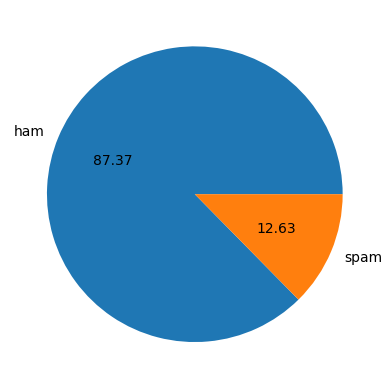

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

**Step 10 : Installing & Importing NLTK for Text Processing**

Installs and downloads the Natural Language Toolkit (NLTK) for text analysis.


In [ ]:
# Data is imbalanced
import nltk
!pip install nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

**step 11 : Feature Engineering: Character Count**

Computes the number of characters in each message.

In [ ]:
df['num_characters'] = df['text'].fillna('').apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


**Step 12 : Feature Engineering: Word Count**

Computes the number of words per message.

In [ ]:
df['num_words'] = df['text'].fillna('').apply(lambda x:len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


**Step 13 : Feature Engineering: Sentence Count**

Computes the number of sentences in each message.


In [ ]:
df['num_sentences'] = df['text'].fillna('').apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


**Step 14 : Statistical Summary of Features**

Provides descriptive statistics of numerical features.

In [ ]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


**Comparing Spam & Ham Messages (Statistics)**



In [ ]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


**Step 15 : Data Visualization: Histograms**

* A histogram is a graphical representation of data distribution.

* Uses bars to show frequency of data in different intervals (bins).

* X-axis: Data ranges (bins), Y-axis: Frequency (count).

* Helps analyze patterns, skewness, and distribution in continuous data.

* Common in statistics, data science, and machine learning

Plots histograms for spam vs. ham messages. **bold text**

<Axes: xlabel='num_words', ylabel='Count'>

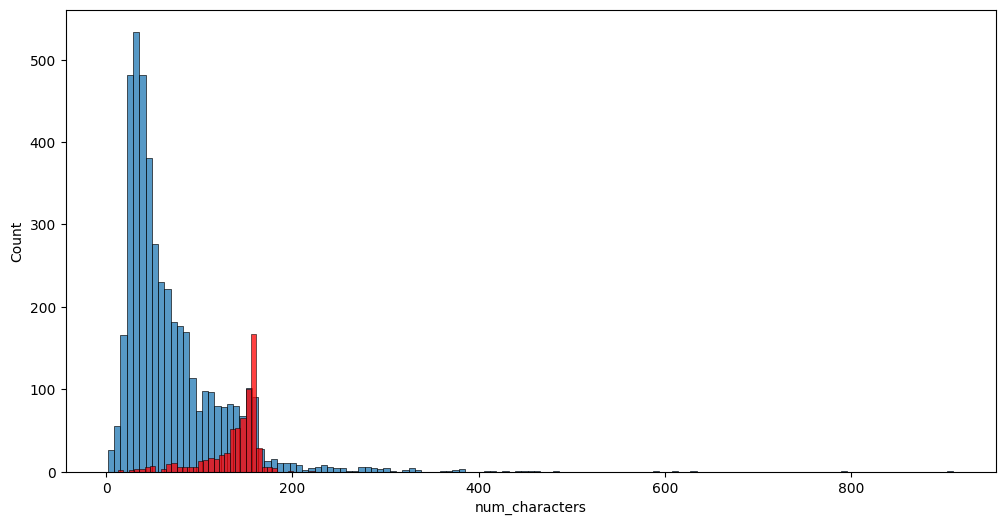

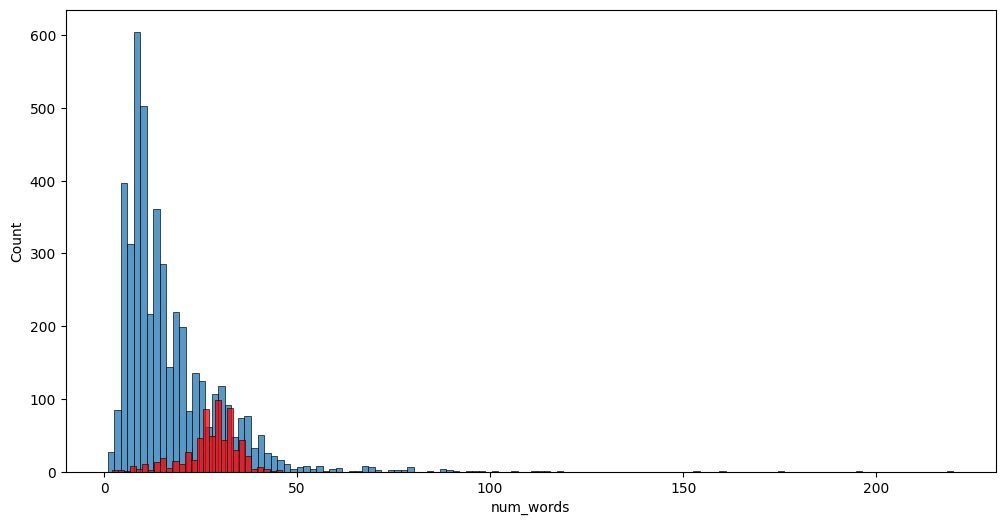

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

**Step 16 : Pairplot for Feature Relationships**

A pair plot is a collection of scatterplots organized in a grid format, showing relationships between pairs of variables in a dataset.

Helps visualize the correlation and distribution of multiple variables.

Visualizes relationships between numerical features.


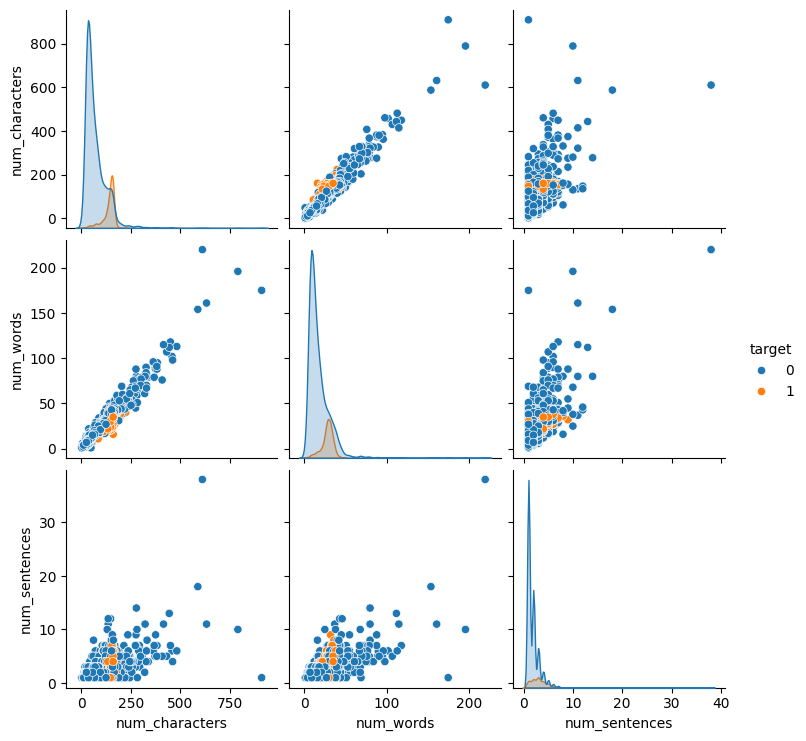

In [ ]:
sns.pairplot(df,hue='target')

**Step 17 : Correlation Heatmap**

1. Relationships: Identify positive or negative feature correlations.

2. Feature Selection: Use strong correlations for model building.

3. Redundancy: Remove highly correlated redundant features.

4. Patterns: Detect data inconsistencies or trends.


Displays the correlation between different numerical features.


<Axes: >

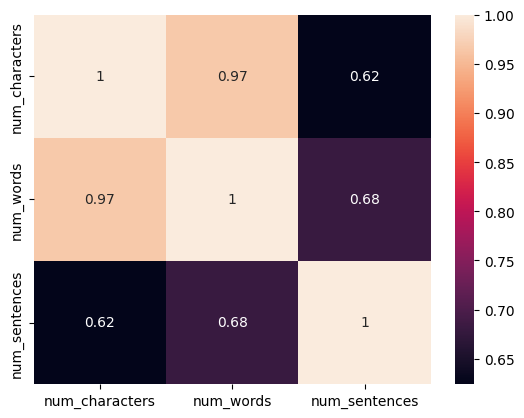

In [ ]:
numerical_features = ['num_characters', 'num_words', 'num_sentences']
sns.heatmap(df[numerical_features].corr(), annot=True)

Step 18 : Data Preprocessing

 Text Preprocessing - Tokenization, Stopword Removal, and Stemming

 Converts text to lowercase, removes punctuation & stopwords, and applies stemming.


In [ ]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [ ]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Download necessary resources
nltk.download('punkt')
nltk.download('stopwords')

# Initialize PorterStemmer
ps = PorterStemmer()

def transform_text(text):
    if not isinstance(text, str):  # Handle cases where input is not a string
        return ""

    text = text.lower()  # Convert to lowercase
    text = nltk.word_tokenize(text)  # Tokenize words

    # Remove non-alphanumeric characters
    text = [word for word in text if word.isalnum()]

    # Remove stopwords and punctuation
    text = [word for word in text if word not in stopwords.words('english') and word not in string.punctuation]

    # Apply stemming
    text = [ps.stem(word) for word in text]

    return " ".join(text)

# Example usage
sample_text = "This is an Example! Text, with Punctuation & Stopwords."
print(transform_text(sample_text))


exampl text punctuat stopword


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


**Step 19 : Word Cloud Visualization for Spam & Ham**

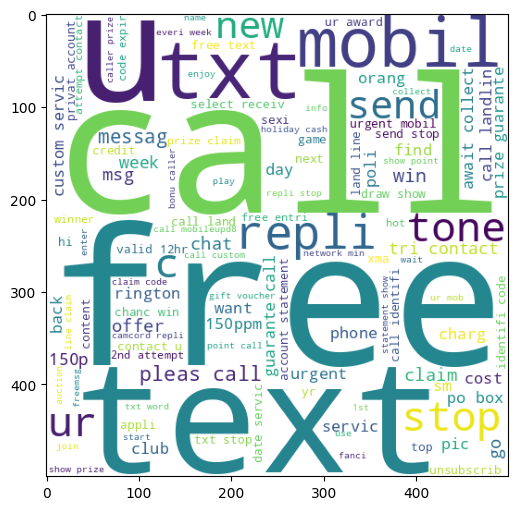

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

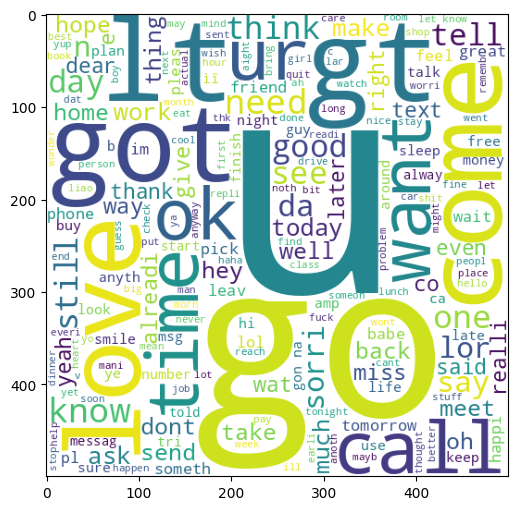

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [ ]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

9939

**Step 20 : Analyzing Most Common Words in Spam & Ham**

Identifies the most frequently used words in spam and ham messages.

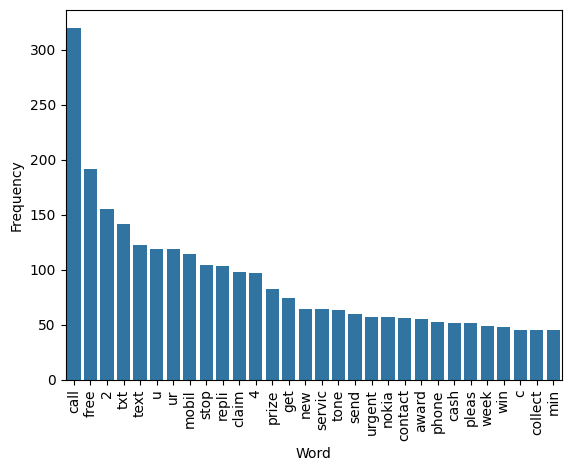

In [ ]:
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the Counter object
spam_corpus_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Frequency'])

# Use the DataFrame in the barplot function
sns.barplot(x='Word', y='Frequency', data=spam_corpus_df)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
len(ham_corpus)

35404

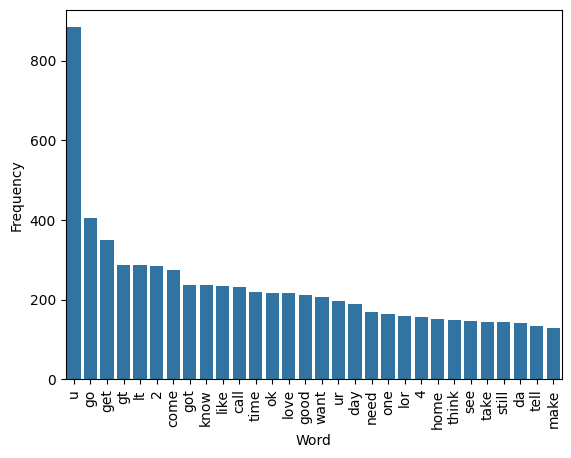

In [ ]:
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from the Counter object
ham_corpus_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Frequency'])

# Use the DataFrame in the barplot function
sns.barplot(x='Word', y='Frequency', data=ham_corpus_df)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


**Step 21 : Text Vectorization Using TF-IDF**

Converts text into numerical features using TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values


**Step 22 : Splitting Data for Training & Testing**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**Step 23 : Training Different Machine Learning Models**

Trains multiple models: Naïve Bayes, Logistic Regression, Random Forest, and SVM.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Initialize models
nb = MultinomialNB()
lr = LogisticRegression()
rf = RandomForestClassifier()
svm = SVC()

# Train models
nb.fit(X_train, y_train)
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)


SVC()

**Step 24 : Check accuracy for different model**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

models = {"Naïve Bayes": nb, "Logistic Regression": lr, "Random Forest": rf, "SVM": svm}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)


Model: Naïve Bayes
Accuracy: 0.9729206963249516
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.81      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034

--------------------------------------------------
Model: Logistic Regression
Accuracy: 0.9584139264990329
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       889
           1       0.95      0.74      0.83       145

    accuracy                           0.96      1034
   macro avg       0.95      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034

--------------------------------------------------
Model: Random Forest
Accuracy: 0.9738878143133463
              precision    recall  f1-score   support

           0       0.97      1.00  

**Step 25 : Perform ENsemble technique**

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble_model = VotingClassifier(estimators=[
    ('nb', nb),
    ('lr', lr),
    ('rf', rf),
    ('svm', svm)
], voting='hard')

ensemble_model.fit(X_train, y_train)

y_pred_ensemble = ensemble_model.predict(X_test)
print(f"Ensemble Model Accuracy: {accuracy_score(y_test, y_pred_ensemble)}")
print(classification_report(y_test, y_pred_ensemble))


Ensemble Model Accuracy: 0.9690522243713733
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       1.00      0.78      0.88       145

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [ ]:
def predict_spam(text):
    transformed_text = transform_text(text)
    vectorized_text = tfidf.transform([transformed_text]).toarray()
    prediction = ensemble_model.predict(vectorized_text)
    return "Spam" if prediction[0] == 1 else "Ham"

# Example usage
print(predict_spam("Congratulations! You've won a free gift. Call now!"))


Spam


**Step 27: Save the model for deployment**

In [ ]:
import joblib
joblib.dump(ensemble_model, 'spam_classifier.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']